In [13]:
import cupy as cp
import math
import random
import matplotlib.pyplot as plt
from model.network import Network
from util.data_loader import DataLoader
from util.checkpoint_manager import CheckpointManager

## Loading the Data

In [14]:
data_loader = DataLoader("input/training.txt", "input/validation.txt", num_merges=1935)
vocabulary = data_loader.get_vocabulary()

Training BPE with 1935 merges...
  merge 100/1935: 'i'+'t ' -> 'it '  (vocab=165)
  merge 200/1935: 'E'+'R' -> 'ER'  (vocab=265)
  merge 300/1935: 'd'+'er' -> 'der'  (vocab=364)
  merge 400/1935: 'st'+'er' -> 'ster'  (vocab=462)
  merge 500/1935: 'n'+'ow ' -> 'now '  (vocab=559)
  merge 600/1935: 'IN'+'IUS:
' -> 'INIUS:
'  (vocab=654)
  merge 700/1935: 'te'+'ll ' -> 'tell '  (vocab=746)
  merge 800/1935: 're'+'d ' -> 'red '  (vocab=845)
  merge 900/1935: 'R'+'I' -> 'RI'  (vocab=940)
  merge 1000/1935: 'me'+'an' -> 'mean'  (vocab=1037)
  merge 1100/1935: 'RUT'+'US:
' -> 'RUTUS:
'  (vocab=1125)
  merge 1200/1935: 'K'+'ATH' -> 'KATH'  (vocab=1214)
  merge 1300/1935: 'b'+'al' -> 'bal'  (vocab=1311)
  merge 1400/1935: 'r'+'en' -> 'ren'  (vocab=1401)
  merge 1500/1935: 'RUM'+'IO:
' -> 'RUMIO:
'  (vocab=1493)
  merge 1600/1935: 'r'+'ough' -> 'rough'  (vocab=1582)
  merge 1700/1935: 'bes'+'eech ' -> 'beseech '  (vocab=1681)
  merge 1800/1935: ':
I'+'t ' -> ':
It '  (vocab=1774)
  merge 1900/19

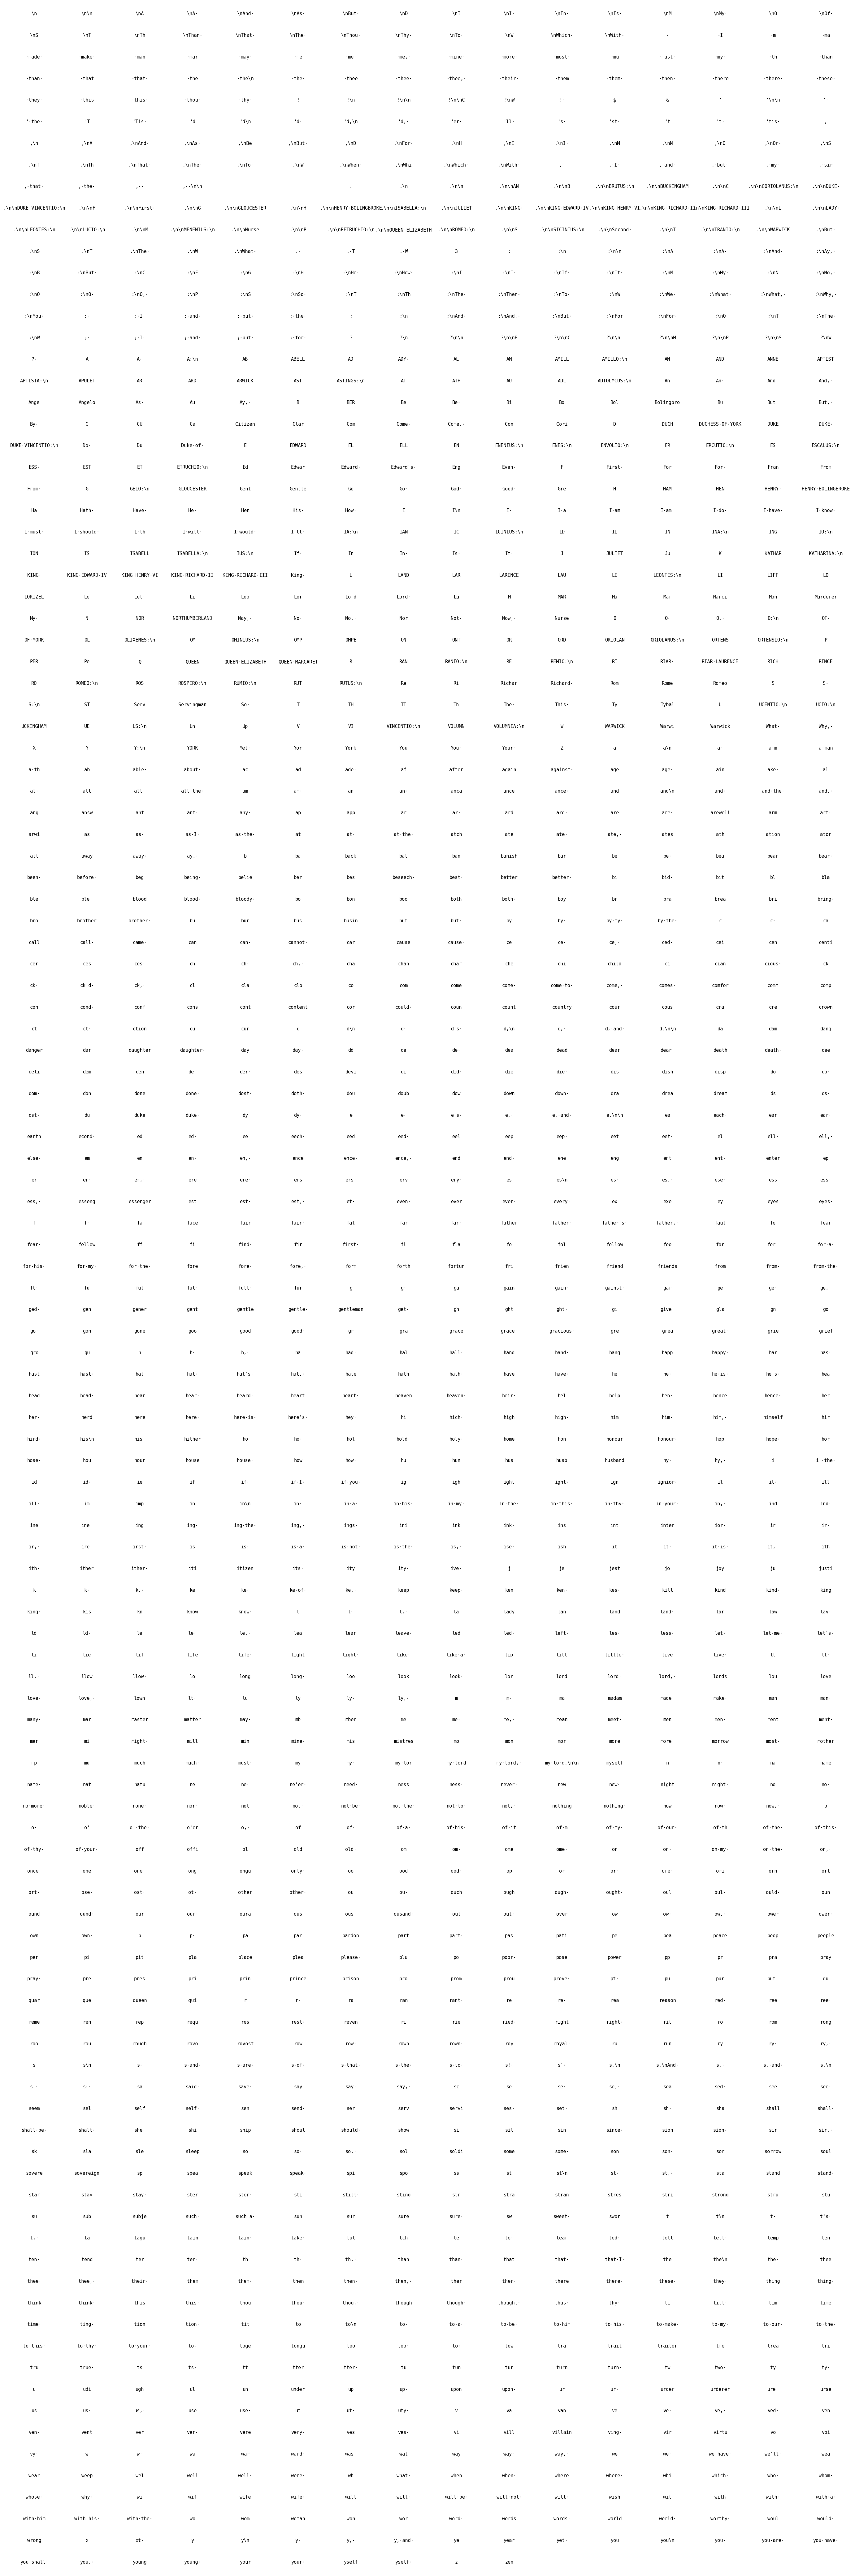

In [15]:
data_loader.plot_vocabulary()

In [16]:
x_train_indices, y_train_indices, x_test_indices, y_test_indices = data_loader.get_indices()

## Building the Model

In [17]:
embedding_dim = 128
hidden_size = 384
hidden2_size = 256

layer_definitions = [
    {"type": "Embedding", "num_embeddings": len(vocabulary), "embedding_dim": embedding_dim},
    {"type": "GatedRecurrent", "input_size": embedding_dim, "num_neurons": hidden_size},
    {"type": "Dropout"},
    {"type": "GatedRecurrent", "input_size": hidden_size, "num_neurons": hidden2_size},
    {"type": "Dropout"},
    {"type": "Softmax", "input_size": hidden2_size, "num_neurons": len(vocabulary)},
]

model = Network(layer_definitions=layer_definitions)
model.describe()


Network Architecture

Layer 1: EmbeddingLayer
  Embeddings Shape: (1898, 128)
  Parameters: 242,944

Layer 2: GatedRecurrentLayer
  Weights Shape: (128, 384) | Recurrent Weights Shape: (384, 384) | Gates: 3
  Parameters: 590,976

Layer 3: DropoutLayer
  Rate: 0.2

Layer 4: GatedRecurrentLayer
  Weights Shape: (384, 256) | Recurrent Weights Shape: (256, 256) | Gates: 3
  Parameters: 492,288

Layer 5: DropoutLayer
  Rate: 0.2

Layer 6: SoftmaxLayer
  Weights Shape: (256, 1898) | Biases Shape: (1898,)
  Parameters: 487,786

Total Parameters: 1,813,994


## Training the Model

In [18]:
def one_hot(indices: cp.ndarray, num_classes: int) -> cp.ndarray:
    encoded = cp.zeros((indices.shape[0], num_classes), dtype=cp.float32)
    encoded[cp.arange(indices.shape[0]), indices] = 1.0
    return encoded

In [19]:
def reshape_streams(
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    max_columns: int | None = None,
 ) -> tuple[cp.ndarray, cp.ndarray]:
    usable_tokens = (x_indices.shape[0] // batch_size) * batch_size
    x = x_indices[:usable_tokens].reshape(batch_size, -1)
    y = y_indices[:usable_tokens].reshape(batch_size, -1)

    if max_columns is not None:
        x = x[:, :max_columns]
        y = y[:, :max_columns]

    return x, y

In [20]:
def evaluate(
    model: Network,
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    sequence_length: int,
    max_steps: int | None = None,
) -> float:
    x, y = reshape_streams(
        x_indices=x_indices,
        y_indices=y_indices,
        batch_size=batch_size,
        max_columns=max_steps,
    )

    model.reset_states(batch_size=batch_size, dtype=cp.float32)
    total_loss = 0.0
    total_steps = x.shape[1]

    for step in range(total_steps):
        y_prob = model.forward(x[:, step])[-1]
        y_true = one_hot(y[:, step], len(vocabulary))
        total_loss += float(model.cce_loss(y_prob, y_true).item())

        if (step + 1) % sequence_length == 0:
            model.reset_states(batch_size=batch_size, dtype=cp.float32)

    return math.exp(total_loss / total_steps)

In [25]:
def train_epoch(
    model: Network,
    x_indices: cp.ndarray,
    y_indices: cp.ndarray,
    batch_size: int,
    sequence_length: int,
    learning_rate: float,
    max_steps: int | None = None,
    weight_decay_lambda: float = 0.0,
    momentum: float = 0.0,
    clip_value: float | None = None,
) -> float:
    model.set_training(True)
    x, y = reshape_streams(
        x_indices=x_indices,
        y_indices=y_indices,
        batch_size=batch_size,
        max_columns=max_steps,
    )
    model.reset_states(batch_size=batch_size, dtype=cp.float32)
    total_loss = 0.0
    total_steps = x.shape[1]

    for chunk_start in range(0, total_steps, sequence_length):
        chunk_end = min(chunk_start + sequence_length, total_steps)
        output_errors = []

        for step in range(chunk_start, chunk_end):
            y_prob = model.forward(x[:, step])[-1]
            y_true = one_hot(y[:, step], len(vocabulary))
            total_loss += float(model.cce_loss(y_prob, y_true).item())
            output_errors.append(y_prob - y_true)

        model.backward_sequence(output_errors, batch_size, clip_value=clip_value)
        model.update_parameters(learning_rate, weight_decay_lambda, momentum)
        model.reset_states(batch_size=batch_size, dtype=cp.float32)

    model.set_training(False)
    return math.exp(total_loss / total_steps)

In [26]:
hyperparameters = {
    "sequence_length": 128,
    "batch_size": 64,
    "epochs": 1000,
    "train_steps_per_epoch": 4096,
    "validation_steps": 1024,
    "base_learning_rate": 1e-5,
    "min_learning_rate": 1e-7,
    "weight_decay_lambda": 1e-3,
    "momentum": 0.9,
    "early_stopping_patience": 200,
    "clip_value": 5.0,
    "checkpoint_interval": 50,
    "dropout_rate": 0.4
}

print(hyperparameters)

{'sequence_length': 128, 'batch_size': 64, 'epochs': 1000, 'train_steps_per_epoch': 4096, 'validation_steps': 1024, 'base_learning_rate': 1e-05, 'min_learning_rate': 1e-07, 'weight_decay_lambda': 0.001, 'momentum': 0.9, 'early_stopping_patience': 200, 'clip_value': 5.0, 'checkpoint_interval': 50, 'dropout_rate': 0.4}


In [27]:
checkpoint_manager = CheckpointManager(file_name="gru_checkpoint.pkl")
best_model, epoch_summaries, best_perplexity = checkpoint_manager.load_checkpoint()

if best_model is not None:
    model = best_model.clone()

max_available_steps = int(x_train_indices.shape[0]) // hyperparameters["batch_size"]
train_steps_per_epoch = min(hyperparameters["train_steps_per_epoch"], max_available_steps)
if train_steps_per_epoch < hyperparameters["train_steps_per_epoch"]:
    print(f"Warning: train_steps_per_epoch clamped from {hyperparameters['train_steps_per_epoch']} to {train_steps_per_epoch} (data too short after BPE compression)")

model.update_dropout_rate(hyperparameters["dropout_rate"])

total_steps = hyperparameters["epochs"] * train_steps_per_epoch
global_step = 0
epochs_without_improvement = 0

slice_size = hyperparameters["batch_size"] * train_steps_per_epoch
max_offset = int(x_train_indices.shape[0]) - slice_size
epoch_offset = len(epoch_summaries)

Loaded checkpoint, best perplexity: 98.0486


In [28]:
for epoch in range(1, hyperparameters["epochs"] + 1):
    learning_rate = hyperparameters["min_learning_rate"] + 0.5 * (hyperparameters["base_learning_rate"] - hyperparameters["min_learning_rate"]) * (1 + math.cos(math.pi * global_step / total_steps))

    offset = random.randint(0, max_offset)
    x_slice = x_train_indices[offset : offset + slice_size]
    y_slice = y_train_indices[offset : offset + slice_size]

    train_perplexity = train_epoch(
        model=model,
        x_indices=x_slice,
        y_indices=y_slice,
        batch_size=hyperparameters["batch_size"],
        sequence_length=hyperparameters["sequence_length"],
        learning_rate=learning_rate,
        weight_decay_lambda=hyperparameters["weight_decay_lambda"],
        momentum=hyperparameters["momentum"],
        clip_value=hyperparameters["clip_value"],
    )
    test_perplexity = evaluate(
        model=model,
        x_indices=x_test_indices,
        y_indices=y_test_indices,
        batch_size=hyperparameters["batch_size"],
        sequence_length=hyperparameters["sequence_length"],
        max_steps=hyperparameters["validation_steps"],
    )

    epoch_summary = {
        "epoch": epoch + epoch_offset,
        "learning_rate": learning_rate,
        "train_perplexity": train_perplexity,
        "test_perplexity": test_perplexity,
        "regularization": train_perplexity / test_perplexity,
    }
    epoch_summaries.append(epoch_summary)

    if (epoch + epoch_offset) % 10 == 0 or epoch == 1:
        print(epoch_summary)

    if test_perplexity < best_perplexity:
        best_perplexity = test_perplexity
        best_model = model.clone()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    global_step += train_steps_per_epoch

    if (epoch + epoch_offset) % hyperparameters["checkpoint_interval"] == 0:
        checkpoint_manager.save_checkpoint(best_model, vocabulary, epoch_summaries)

    if epochs_without_improvement >= hyperparameters["early_stopping_patience"]:
        print(f"Early stopping triggered after {epoch + epoch_offset} epochs due to no improvement.")
        break

{'epoch': 1151, 'learning_rate': 1e-05, 'train_perplexity': 85.74199074281667, 'test_perplexity': 98.0762022584117, 'regularization': 0.8742384877108437}
{'epoch': 1160, 'learning_rate': 9.99802152286877e-06, 'train_perplexity': 85.81875060462256, 'test_perplexity': 98.10741422454396, 'regularization': 0.8747427631535}
{'epoch': 1170, 'learning_rate': 9.991184373127149e-06, 'train_perplexity': 85.43995442148582, 'test_perplexity': 98.11862290628805, 'regularization': 0.8707822418491189}
{'epoch': 1180, 'learning_rate': 9.97947087096567e-06, 'train_perplexity': 85.59057934450128, 'test_perplexity': 98.11731013864072, 'regularization': 0.8723290439124447}
{'epoch': 1190, 'learning_rate': 9.962892576196779e-06, 'train_perplexity': 85.5679134999004, 'test_perplexity': 98.13406448002584, 'regularization': 0.8719491437890748}
{'epoch': 1200, 'learning_rate': 9.94146584959589e-06, 'train_perplexity': 85.5929513908106, 'test_perplexity': 98.13479633417688, 'regularization': 0.8721977788524904}

In [29]:
print(f"Best validation perplexity: {best_perplexity:.6f}")
checkpoint_manager.save_checkpoint(best_model, vocabulary, epoch_summaries)

Best validation perplexity: 98.048588
  Checkpoint saved -> checkpoints\gru_checkpoint.pkl


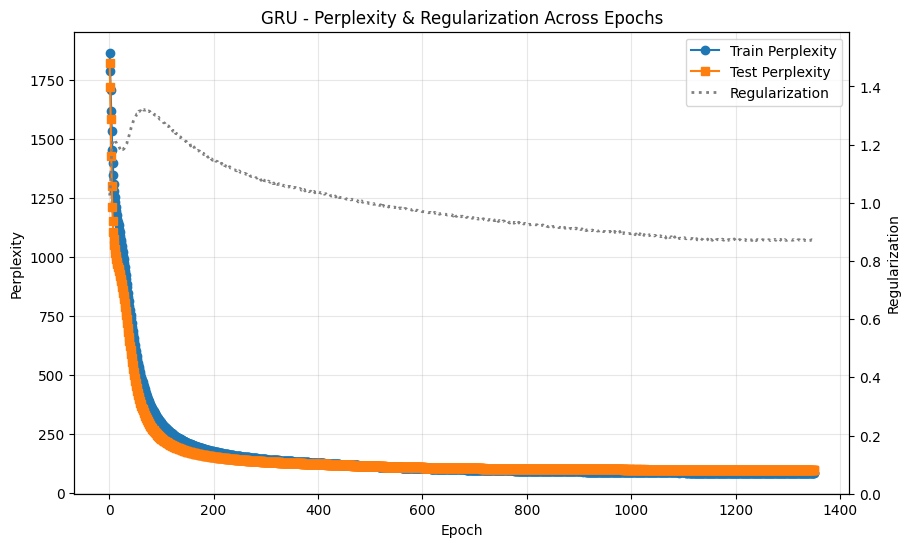

In [30]:
epochs_plot = [summary["epoch"] for summary in epoch_summaries]
train_perplexities = [summary["train_perplexity"] for summary in epoch_summaries]
test_perplexities = [summary["test_perplexity"] for summary in epoch_summaries]
regularizations = [summary["regularization"] for summary in epoch_summaries]

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(epochs_plot, train_perplexities, marker="o", label="Train Perplexity")
ax1.plot(epochs_plot, test_perplexities, marker="s", label="Test Perplexity")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Perplexity")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(epochs_plot, regularizations, color="gray", linestyle=":", linewidth=2, label="Regularization")
ax2.set_ylim(0, max(regularizations) * 1.2)
ax2.set_ylabel("Regularization")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.title("GRU - Perplexity & Regularization Across Epochs")
plt.show()

In [31]:
def generate_text(
    model: Network,
    seed_text: str,
    length: int = 250,
    temperature: float = 0.8,
    print_during: bool = True,
) -> str:
    model.reset_states(batch_size=1, dtype=cp.float32)
    seed_tokens = data_loader.encode(seed_text)
    generated = list(seed_tokens)

    if print_during:
        print(seed_text, end="")

    for token in seed_tokens:
        token_index = cp.asarray([data_loader.char_to_index(token)], dtype=cp.int32)
        model.forward(token_index)

    current_token = seed_tokens[-1]

    for _ in range(length):
        token_index = cp.asarray([data_loader.char_to_index(current_token)], dtype=cp.int32)
        y_prob = model.forward(token_index)[-1][0]
        log_prob = cp.log(y_prob + 1e-9) / temperature
        scaled_prob = cp.exp(log_prob - cp.max(log_prob))
        scaled_prob = scaled_prob / cp.sum(scaled_prob)
        next_index = int(
            cp.random.choice(len(vocabulary), size=1, p=scaled_prob)[0].item()
        )
        current_token = data_loader.index_to_char(next_index)
        generated.append(current_token)

        if print_during:
            print(current_token, end="", flush=True)

    return data_loader.decode(generated)


In [32]:
generated = generate_text(model=best_model, seed_text="DANIEL", length=500, temperature=0.8)

DANIEL:
No, sweet Norfolk, Lady:
Let's thanks the news go; and that yet I have quit by him;
And that peak you to the world. Could he and suitep to the maid; who what, most fears,
Must and his chamber-deed for his sisters forfit.
Why, 'tis my good past. Where I beseech him; 'tis very longer
Surious flatters have unworthy numbers;
And therefore you must do not remaid: from all wrong;
I bear a pipls me deny you a compurse,
Pence of this one naver syouth beat refuspence.

LEONTES:
Wortensisters a lack
For more ower already to go ago
Last I you, good virgining guilty
Than dlifg, with his buts cannot satisfied
Our city consent you myself.

ESCALUS:
Nay, as he would toth, no more, fair rap of death here?
Have we remembly mal of him.

CORIOLANUS:
Come on that I didst thou. By this bed;
My Montague from the life, may be not like show me.
My heart is musts the ceed
thee, comest tags and heaven, wthan is frest,
Unless his good,
As well she be retarinous meath a wind?
Madam, as he wark'd without w